|<img style="float:left;" src="images/usherb_transp.gif" > |<big><big><big><big>Pierre Proulx, ing, professeur|
|:---|:---|
|<big><big>Département de génie chimique et de génie biotechnologique |<big><big><big><big> GCH200-Phénomènes d'échanges I </big></big>|



#  Chapitre 6: Facteurs de friction:
____
____
____
____
# 1 Définition 


>> ### Le facteur de friction est facteur de proportionnalité défini comme le rapport entre la force de friction exercée sur un objet par un fluide qui s'écoule sur cet objet d'une part, et le produit de l'énergie cinétique du fluide multipliée par la surface. On peut aussi écrire ce coefficient comme le rapport entre la pression exercée sur l'objet par la force de trainée et la pression dynamique du fluide. 

 $$ \boxed { { f  } = \frac {\frac {F_k}{A}}{ \frac {1}{2} \rho V^2}}$$

a) Le facteur de friction défini pour l'écoulement dans une conduite devient ainsi: 
$$
  \boxed{ f = \frac {F_k}{2 \pi R L \big( \frac {1}{2} \rho V^2\big)} }
  $$

$ V $ est la vitesse moyenne de l'écoulement dans la conduite. 

Par un bilan des forces qui s'exercent sur la conduite, on peut relier la force de friction à la différence de pression $\mathscr{P}_0 - \mathscr{P}_L$, et on obtient:

$$
\boxed {F_k = (\mathscr{P}_0 - \mathscr{P}_L)\pi R^2}
$$

En substituant $F_k$ dans la définition de $f$, on obtient la définition générale du coefficient de friction pour une conduite circulaire:

$$
  \boxed{ f =  \frac {1}{4} \frac {D}{L}\frac {\mathscr{P}_0 - \mathscr{P}_L} {(\frac {1}{2} \rho V^2)}} 
  $$

### b) Le facteur de friction défini pour l'écoulement autour d'une sphère en chute libre : 
Le facteur de friction est toujours défini de la même façon

$$ \boxed {f = \frac {\frac {F_k}{A}}{ \frac {1}{2} \rho v_\infty ^2}}$$

mais ici, **attention**, la surface A est la surface projetée de la sphère, donc la surface d'un disque, et $v_\infty $ est la vitesse relative entre le fluide et la sphère.

$$
  \boxed{ f = \frac {F_k}{\pi R^2 \frac {1}{2} \rho v_\infty^2}}
  $$

Par un bilan des forces qui s'exercent sur la sphère (gravité - poussée d'Archimède), on obtient:

$$
\boxed {F_k = \frac {4}{3}\pi R^3 \rho_{sph} g - \frac {4}{3}\pi R^3 \rho g  }
$$

En substituant $F_k$ dans la définition de $f$, on obtient la définition générale du coefficient de friction pour une sphère en chute libre:

$$
  \boxed{ f =  \frac {4}{3} \frac {gD}{v_\infty ^2} \frac {\rho_{sph} -\rho} {\rho}} 
  $$

In [1]:
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
%matplotlib inline
import matplotlib.pyplot as plt
import fluids as fl
import thermo as th
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

____
____
____
____
# 3. Facteur de friction pour une sphère en chute libre

Le résultat obtenu dans la section 1b) est la définition du facteur de friction, ce facteur peut maintenant être déterminé si on connait le profil de vitesse autour de la sphère. La solution n'est pas unique, encore une fois, mais dépends du régime d'écoulement. 

####  * Régime de Stokes, pour des nombres de Reynolds très faibles ( < 1 ) 

Dans ce cas, le facteur de friction peut être obtenu:
$$
\boxed {f = \frac {24}{Re}}
$$

####  * Régime intermédiaire,  ( 500 > Re  > 1  ) 

Dans ce cas, le facteur de friction peut être obtenu par:
$$
\boxed {f = \bigg ( \sqrt{\frac {24}{Re}} + 0.5407 \bigg )^2}
$$

####  * Régime de Newton,  ( 100000> Re  >500 ) 

Expérimentalement on a trouvé que dans cette région le facteur de friction varie très peu:
$$
\boxed {f = 0.44}
$$

In [2]:
#
# Utilisons Sympy pour tracer et voir l'influence de Re et k/D,
# ainsi que la cohérence entre les 2 corrélations
# turbulente ainsi que la partie laminaire
#
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
%matplotlib inline
Re,f=sp.symbols('Re,f')
f2=0.44
f1=((24/Re)**0.5+0.5407)**2
f=24/Re
plt.rcParams['figure.figsize'] = 8,6

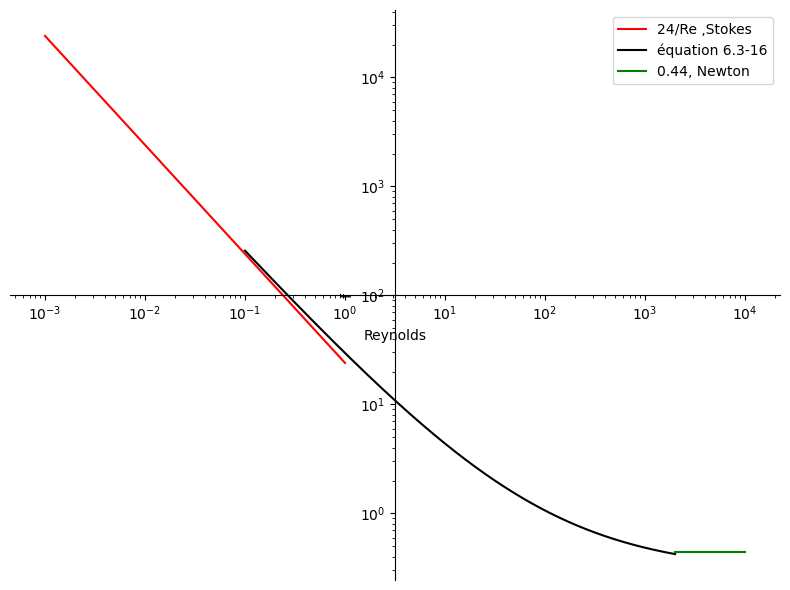

In [3]:
p=sp.plot((f,(Re,0.001,1)),
        (f1,(Re,0.1,2000)),
        (f2,(Re,2000,10000)),
          legend=True,xlabel='Reynolds',ylabel='f',\
          xscale='log',yscale='log',show=False);
p[0].line_color = 'red'
p[0].label='24/Re ,Stokes '
p[1].line_color = 'black'
p[1].label='équation 6.3-16'
p[2].line_color = 'green'
p[2].label='0.44, Newton'
p.show()

### Utilisation de *fluids*

In [4]:
def facteurDeFrictionParticuleFluids(Rep):
    f=fl.drag_sphere(Rep)
    print('Coefficient de trainée de la particule, calculé avec fluids pour Rep={:6.2f}'.format(Rep))
interactive(facteurDeFrictionParticuleFluids,\
            Rep=widgets.FloatLogSlider(value=1,base=10,min=-2,max=5,step=0.1))

interactive(children=(FloatLogSlider(value=1.0, description='Rep', max=5.0, min=-2.0), Output()), _dom_classes…

In [5]:
def VitesseDeChuteLibreFluids(Dp,rhop,rho,mu):
    v=fl.v_terminal(Dp,rhop,rho,mu)
    print('Vitesse terminale de chute libre {:6.4e} m/sec'.format(v))
interactive(VitesseDeChuteLibreFluids,\
            Dp=widgets.FloatLogSlider(description='Dp m',value=1e-3,base=10,min=-5,max=-1,step=0.1),\
           rhop=widgets.FloatLogSlider(description='rhop kg/m**3',value=1000,base=10,min=-1,max=4,step=0.1),\
           rho=widgets.FloatLogSlider(description='rho  kg/m**3',value=1000,base=10,min=-1,max=4,step=0.1),\
           mu=widgets.FloatLogSlider(description='mu kg/m-s',value=1e-3,base=10,min=-5,max=-1,step=0.1))

interactive(children=(FloatLogSlider(value=0.001, description='Dp m', max=-1.0, min=-5.0), FloatLogSlider(valu…